## understanding the ML part

https://colab.research.google.com/drive/1fY6gVynI9cwPvwoanUCHwWR4dhQqTkQX#scrollTo=UkawPpyYcNPa

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from typing import Dict, Any, List
from sklearn.model_selection import KFold
import statsmodels.api as sm
from scipy.stats import multivariate_normal

### download data

In [2]:
df_data = pd.read_csv("https://cdn.shopify.com/s/files/1/0577/5602/4854/files/demand_data.csv?v=1761531776")
df_data

,Price_Milk,Price_Chocolate,Price_Soup,Price_Ramen,Demand_Milk,Demand_Chocolate,Demand_Soup,Demand_Ramen
0,4.68,5.77,4.52,3.12,653,69,146,66
1,2.61,6.64,5.97,2.97,1557,98,143,129
2,2.77,3.60,3.90,2.43,816,142,208,243
3,3.61,7.64,3.76,2.81,951,52,228,109
4,2.74,2.69,4.46,2.24,1315,208,170,294
...,...,...,...,...,...,...,...,...
9995,4.29,5.68,2.77,0.75,761,73,197,985
9996,5.30,5.85,3.40,1.30,422,60,146,399
9997,5.47,5.29,2.07,2.92,378,94,235,57
9998,1.65,2.72,4.01,0.86,2492,262,146,1448


### initial plotting
plotting some histograms, demand vs price plots to understand the data bit better:

np.int64(476)

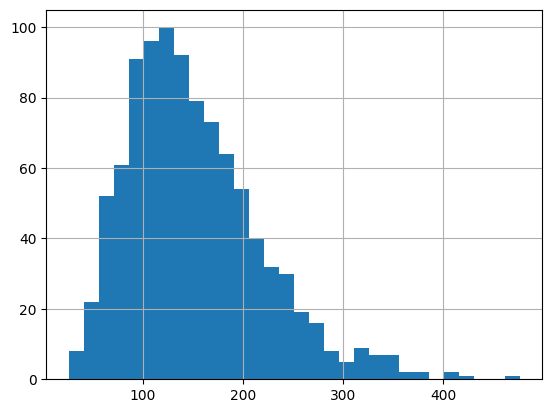

In [3]:
sel = (df_data['Price_Soup']>4.5-0.2) & (df_data['Price_Soup']<4.5+0.2)
df_data['Demand_Soup'][sel].hist(bins=30)
np.max(df_data['Demand_Soup'][sel])

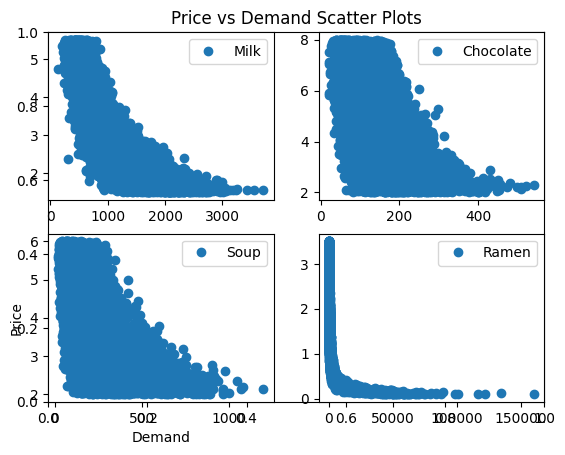

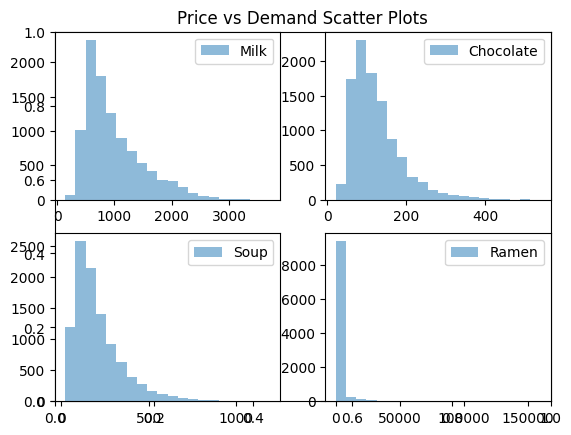

In [4]:
plt.figure()
plt.title("Price vs Demand Scatter Plots")
plt.subplot(2,2,1)
plt.plot(df_data['Demand_Milk'], df_data['Price_Milk'],marker='o', linestyle='',label="Milk")
plt.legend()
plt.subplot(2,2,2)
plt.plot(df_data['Demand_Chocolate'], df_data['Price_Chocolate'],marker='o', linestyle='',label="Chocolate")
plt.legend()
plt.subplot(2,2,3)
plt.plot(df_data['Demand_Soup'], df_data['Price_Soup'],marker='o', linestyle='',label="Soup")
plt.legend()
plt.xlabel("Demand")
plt.ylabel("Price")
plt.subplot(2,2,4)
plt.plot(df_data['Demand_Ramen'], df_data['Price_Ramen'],marker='o', linestyle='',label="Ramen")
plt.legend()

plt.figure()
plt.title("Price vs Demand Scatter Plots")
plt.subplot(2,2,1)
plt.hist(df_data['Demand_Milk'], bins=20, alpha=0.5, label='Milk');
plt.legend()
plt.subplot(2,2,2)
plt.hist(df_data['Demand_Chocolate'], bins=20, alpha=0.5, label='Chocolate');
plt.legend()
plt.subplot(2,2,3)
plt.hist(df_data['Demand_Soup'], bins=20, alpha=0.5, label='Soup');
plt.legend()
plt.subplot(2,2,4)
plt.hist(df_data['Demand_Ramen'], bins=20, alpha=0.5, label='Ramen');
plt.legend()


typical relation between prize and demand:
- high prize -> lower demand
- lower prize -> higher demand

later in the Colab a `log()` transformation is applied to this dataset (which can be beneficial: [*"When our original continuous data do not follow the bell curve, we can log transform this data to make it as “normal” as possible so that the statistical analysis results from this data become more valid"*](https://medium.com/@kyawsawhtoon/log-transformation-purpose-and-interpretation-9444b4b049c9))


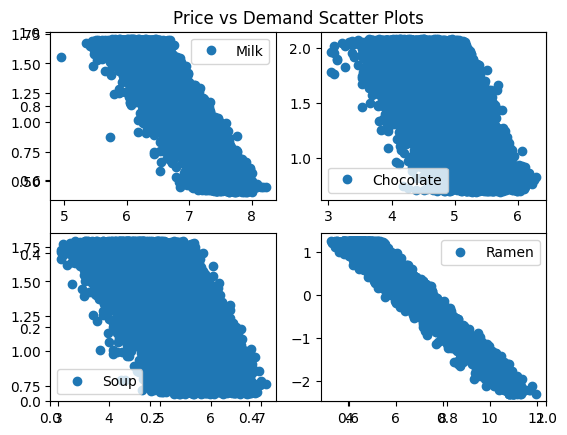

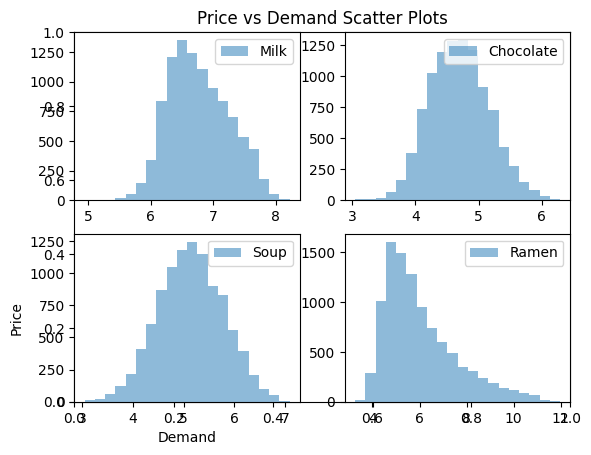

In [5]:
X_cols = ['Price_Milk', 'Price_Chocolate', 'Price_Soup', 'Price_Ramen']
Y_cols = ['Demand_Milk', 'Demand_Chocolate', 'Demand_Soup', 'Demand_Ramen']

# --- 0. Apply Log Transformation ---
df_log = pd.DataFrame()
for col in X_cols:
    df_log[f'log_{col}'] = np.log(df_data[col])
for col in Y_cols:
    df_log[f'log_{col}'] = np.log(df_data[col])

X_log_cols = [f'log_{col}' for col in X_cols]
Y_log_cols = [f'log_{col}' for col in Y_cols]


plt.figure
plt.title("Price vs Demand Scatter Plots")
plt.subplot(2,2,1)
plt.plot(df_log[Y_log_cols[0]], df_log[X_log_cols[0]],marker='o', linestyle='',label="Milk")
plt.legend()
plt.subplot(2,2,2)
plt.plot(df_log[Y_log_cols[1]], df_log[X_log_cols[1]],marker='o', linestyle='',label="Chocolate")
plt.legend()
plt.subplot(2,2,3)
plt.plot(df_log[Y_log_cols[2]], df_log[X_log_cols[2]],marker='o', linestyle='',label="Soup")
plt.legend()
plt.subplot(2,2,4)
plt.plot(df_log[Y_log_cols[3]], df_log[X_log_cols[3]],marker='o', linestyle='',label="Ramen")
plt.legend()

plt.figure()
plt.title("Price vs Demand Scatter Plots")
plt.subplot(2,2,1)
plt.hist(df_log[Y_log_cols[0]], bins=20, alpha=0.5, label='Milk');
plt.legend()
plt.subplot(2,2,2)
plt.hist(df_log[Y_log_cols[1]], bins=20, alpha=0.5, label='Chocolate');
plt.legend()
plt.subplot(2,2,3)
plt.hist(df_log[Y_log_cols[2]], bins=20, alpha=0.5, label='Soup');
plt.legend()
plt.xlabel("Demand")
plt.ylabel("Price")
plt.subplot(2,2,4)
plt.hist(df_log[Y_log_cols[3]], bins=20, alpha=0.5, label='Ramen');
plt.legend()

log transformation results in a demand distribution which is more close to a normal distribution and further the relation between demand and prize is more linear!

The latter fact is probably the motivation in the Colab to use an OLS for modeling the relation between price and demand

In [6]:
X_log_cols

['log_Price_Milk', 'log_Price_Chocolate', 'log_Price_Soup', 'log_Price_Ramen']

### Analyse the provided baseline solution to forecast the demands (from the Colab)

The mentioned Colab above provides the following functions for forecasting:

In [7]:
def prepare_forecaster(df: pd.DataFrame) -> Dict[str, Any]:
    """
    Pre-calculates all necessary parameters (OLS coefficients and the
    out-of-sample log-residual covariance matrix) for efficient forecasting.

    Args:
        df (pd.DataFrame): The DataFrame containing the demand data.

    Returns:
        Dict[str, Any]: A dictionary containing the fitted OLS model coefficients
                        and the regularized covariance matrix (Sigma).
    """
    X_cols = ['Price_Milk', 'Price_Chocolate', 'Price_Soup', 'Price_Ramen']
    Y_cols = ['Demand_Milk', 'Demand_Chocolate', 'Demand_Soup', 'Demand_Ramen']

    # --- 0. Apply Log Transformation ---
    df_log = pd.DataFrame()
    for col in X_cols:
        df_log[f'log_{col}'] = np.log(df[col])
    for col in Y_cols:
        df_log[f'log_{col}'] = np.log(df[col])

    X_log_cols = [f'log_{col}' for col in X_cols]
    Y_log_cols = [f'log_{col}' for col in Y_cols]

    # --- 1. Fit Full OLS Models and Extract Coefficients (for Mean Vector mu) ---
    X_full = sm.add_constant(df_log[X_log_cols])
    coef_dict = {}

    for y_log_col in Y_log_cols:
        model = sm.OLS(df_log[y_log_col], X_full).fit()
        # Save the coefficients (including the intercept 'const')
        coef_dict[y_log_col] = model.params.values

    # --- 2. Compute Out-of-Sample Residuals using 10-Fold CV (for Covariance Sigma) ---
    kf = KFold(n_splits=10, shuffle=True, random_state=42)
    out_of_sample_log_residuals = pd.DataFrame(index=df_log.index, columns=Y_log_cols, dtype=float)

    for train_index, test_index in kf.split(df_log):
        df_train, df_test = df_log.iloc[train_index], df_log.iloc[test_index]
        X_train = sm.add_constant(df_train[X_log_cols])
        X_test = sm.add_constant(df_test[X_log_cols])

        for y_log_col in Y_log_cols:
            model_cv = sm.OLS(df_train[y_log_col], X_train).fit()
            predictions = model_cv.predict(X_test)
            log_residuals = df_test[y_log_col] - predictions
            out_of_sample_log_residuals.loc[test_index, y_log_col] = log_residuals

    # --- 3. Compute and Regularize Covariance Matrix (Sigma) ---
    Sigma_log = out_of_sample_log_residuals.cov()
    regularization_factor = 1e-3
    Sigma_regularized = Sigma_log + np.identity(Sigma_log.shape[0]) * regularization_factor

    # --- 4. Return Pre-calculated Forecaster Object ---
    return {
        'coefficients': coef_dict,
        'Sigma': Sigma_regularized,
        'X_log_cols': X_log_cols,
        'Y_cols': Y_cols # Use original demand names for final output
    }

print("--- Preparing Forecaster (Fitting Models and Calculating Sigma) ---")
forecaster_obj = prepare_forecaster(df_data)
print("Preparation complete. Forecaster object is ready.")

--- Preparing Forecaster (Fitting Models and Calculating Sigma) ---
Preparation complete. Forecaster object is ready.


In [8]:
forecaster_obj

{'coefficients': {'log_Demand_Milk': array([ 8.19941780e+00, -1.19518960e+00, -4.25970453e-04, -1.32877440e-03,
          1.63855215e-03]),
  'log_Demand_Chocolate': array([ 6.87411831e+00, -7.94804718e-01, -7.99229733e-01,  5.42476893e-03,
          4.73580237e-04]),
  'log_Demand_Soup': array([ 7.80659375e+00, -7.88151747e-01, -4.33514333e-03, -1.39913697e+00,
          3.98698098e-01]),
  'log_Demand_Ramen': array([ 7.16790679e+00, -7.94730295e-01, -3.79621429e-03,  4.01535386e-01,
         -1.89924407e+00])},
 'Sigma':                       log_Demand_Milk  log_Demand_Chocolate  log_Demand_Soup  \
 log_Demand_Milk              0.045351             -0.000107         0.000595   
 log_Demand_Chocolate        -0.000107              0.046218         0.000053   
 log_Demand_Soup              0.000595              0.000053         0.046743   
 log_Demand_Ramen            -0.000524             -0.000032        -0.000436   
 
                       log_Demand_Ramen  
 log_Demand_Milk       

In [9]:
def expected_joint_demand(prices: List[float], forecaster: Dict[str, Any]) -> List[float]:

    log_prices = np.log(prices)

    # Construct the predictor vector (X_new = [1, log(P_1), log(P_2), ...])
    X_new_vector = np.array([1.0] + log_prices.tolist())

    mu_log_forecasts = []

    # --- 1. Calculate Mean Vector (mu_log) using pre-calculated coefficients ---
    for y_log_col in forecaster['coefficients']:
        # mu = X_new_vector @ beta (dot product)
        beta_vector = forecaster['coefficients'][y_log_col]
        mu_log = np.dot(X_new_vector, beta_vector)
        mu_log_forecasts.append(mu_log)

    mu_log_array = np.array(mu_log_forecasts)
    return list(np.exp(mu_log_array).tolist())

In [10]:
prices_1 = [3.00, 2.50, 3.50, 1.80]
expected_1 = expected_joint_demand(prices_1, forecaster_obj)
expected_1
prices_2 = [3.50, 3.50, 2.50, 3.20]
expected_2 = expected_joint_demand(prices_2, forecaster_obj)
prices_3 = [4.50, 6.0, 4.50, 0.80]
expected_3 = expected_joint_demand(prices_3, forecaster_obj)

plot distribution vs the `expected_joint_demand()` output --> point estimate!!!

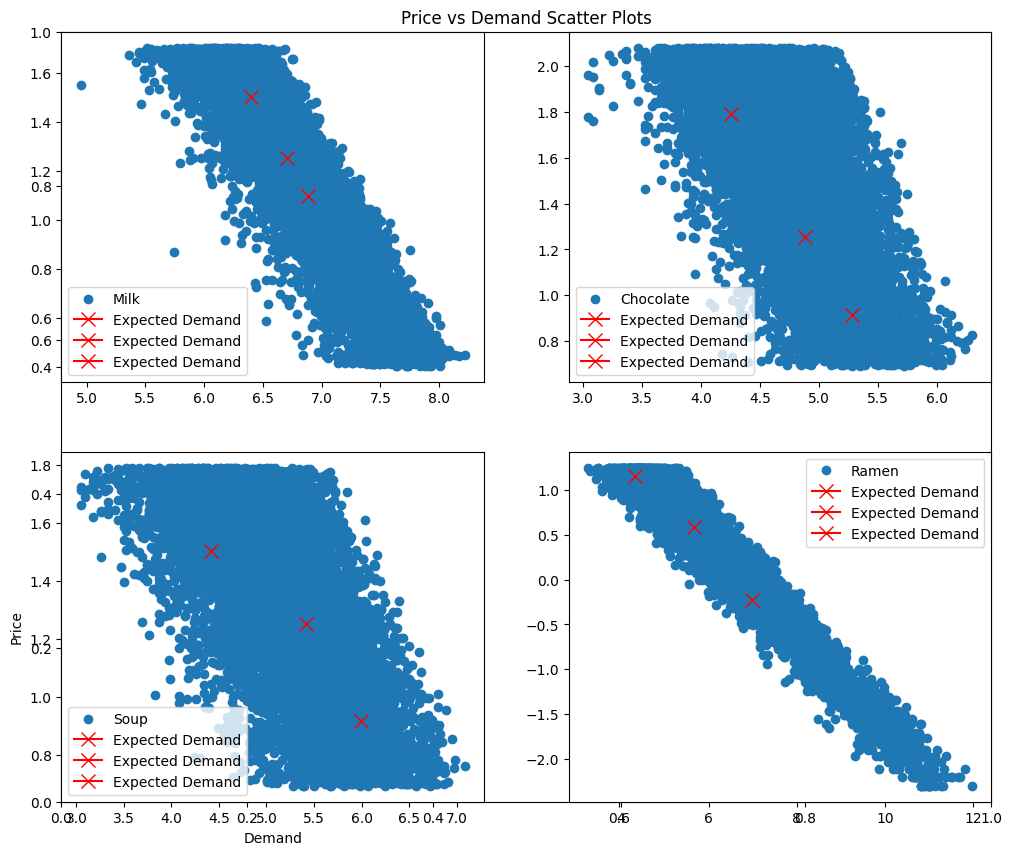

In [11]:
plt.figure(figsize=(12, 10))
plt.title("Price vs Demand Scatter Plots")
plt.subplot(2,2,1)
plt.plot(df_log[Y_log_cols[0]], df_log[X_log_cols[0]],marker='o', linestyle='',label="Milk")
plt.plot(np.log(expected_1[0]), np.log(prices_1[0]), marker='x', color='red', markersize=10, label='Expected Demand')
plt.plot(np.log(expected_2[0]), np.log(prices_2[0]), marker='x', color='red', markersize=10, label='Expected Demand')
plt.plot(np.log(expected_3[0]), np.log(prices_3[0]), marker='x', color='red', markersize=10, label='Expected Demand')
plt.legend()
plt.subplot(2,2,2)
plt.plot(df_log[Y_log_cols[1]], df_log[X_log_cols[1]],marker='o', linestyle='',label="Chocolate")
plt.plot(np.log(expected_1[1]), np.log(prices_1[1]), marker='x', color='red', markersize=10, label='Expected Demand')
plt.plot(np.log(expected_2[1]), np.log(prices_2[1]), marker='x', color='red', markersize=10, label='Expected Demand')
plt.plot(np.log(expected_3[1]), np.log(prices_3[1]), marker='x', color='red', markersize=10, label='Expected Demand')
plt.legend()
plt.subplot(2,2,3)
plt.plot(df_log[Y_log_cols[2]], df_log[X_log_cols[2]],marker='o', linestyle='',label="Soup")
plt.plot(np.log(expected_1[2]), np.log(prices_1[2]), marker='x', color='red', markersize=10, label='Expected Demand')
plt.plot(np.log(expected_2[2]), np.log(prices_2[2]), marker='x', color='red', markersize=10, label='Expected Demand')
plt.plot(np.log(expected_3[2]), np.log(prices_3[2]), marker='x', color='red', markersize=10, label='Expected Demand')
plt.legend()
plt.xlabel("Demand")
plt.ylabel("Price")
plt.subplot(2,2,4)
plt.plot(df_log[Y_log_cols[3]], df_log[X_log_cols[3]],marker='o', linestyle='',label="Ramen")
plt.plot(np.log(expected_1[3]), np.log(prices_1[3]), marker='x', color='red', markersize=10, label='Expected Demand')
plt.plot(np.log(expected_2[3]), np.log(prices_2[3]), marker='x', color='red', markersize=10, label='Expected Demand')
plt.plot(np.log(expected_3[3]), np.log(prices_3[3]), marker='x', color='red', markersize=10, label='Expected Demand')
plt.legend()

deeper understanding the model:

- look at soup with close to `price_3` in the above plot --> soup prize 4.5 (log(4.5)~1.5), leads to roughly 4.5 demand (logarithmic)

now compare this to:
- get all (log) demand (raw) data for soup with prices close by `price_3`
- plot histogram - what price would a pure look at this histogram give us?

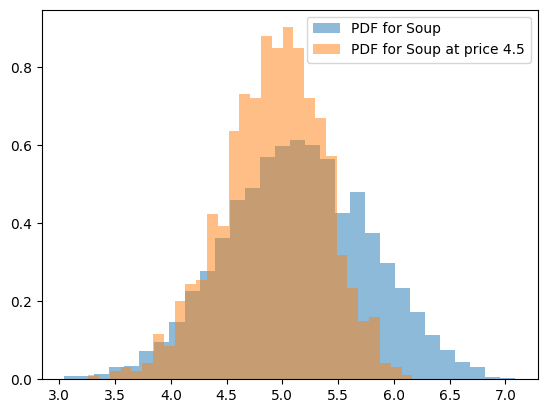

In [12]:
sel = (df_log[X_log_cols[2]] > np.log(prices_3[2]-0.2)) & (df_log[X_log_cols[2]] < np.log(prices_3[2]+0.2))

plt.hist(df_log[Y_log_cols[2]], bins=30, alpha=0.5, label='PDF for Soup',density=True);
plt.hist(df_log[Y_log_cols[2]][sel], bins=30, alpha=0.5, label='PDF for Soup at price ' + str(np.round(np.exp(np.log(prices_3[2])), 2)),density=True);
plt.legend()

mean here would be around 5, the OLS model gives us ~4.5 --> due to correlation from the other prices!
This tells us, that just looking at the histogram for one demand for a given prize is not enough, the demand is also influenced by the others products prizes (see later)

Now check how good the model is in estimating the mean:


MAE (lin scale): 130.16594894222712
MAE (log scale): 0.16406695799588542
R² : 0.8638893180838265


Text(0, 0.5, 'Predicted (lin scale)')

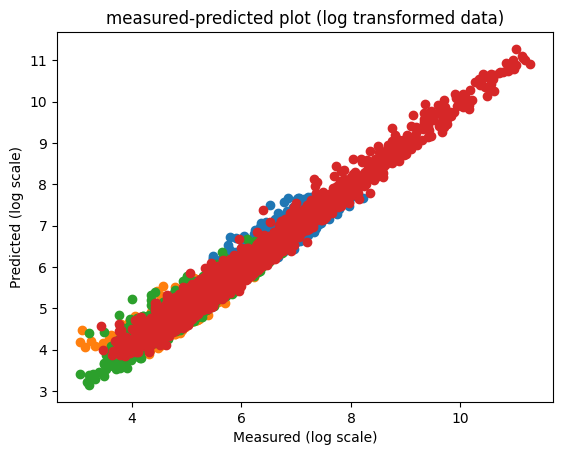

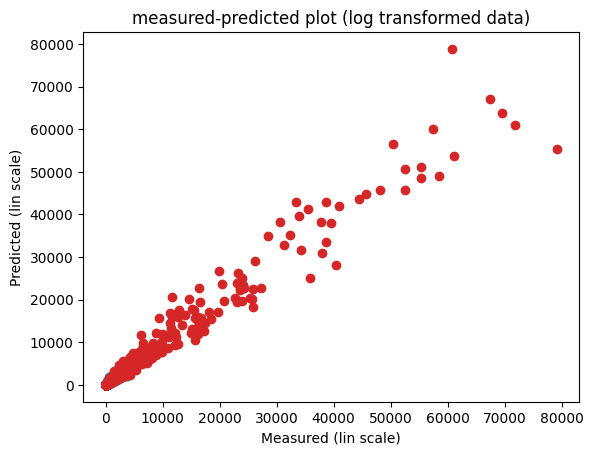

In [13]:
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

X = df_data[X_cols]
y = df_data[Y_cols]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

preds=[]
for row in X_test.values:
    pred = expected_joint_demand(row, forecaster_obj)
    preds.append(pred)
preds = np.column_stack(preds)
preds=preds.T

print('MAE (lin scale):', mean_absolute_error(y_test, preds))
print('MAE (log scale):', mean_absolute_error(np.log(y_test), np.log(preds)))
print('R² :', r2_score(y_test, preds))

plt.figure()
plt.title('measured-predicted plot (log transformed data)')
plt.plot(np.log(y_test),np.log(preds),marker='o', linestyle='');
plt.xlabel('Measured (log scale)')
plt.ylabel('Predicted (log scale)')

plt.figure()
plt.title('measured-predicted plot (log transformed data)')
plt.plot(y_test,preds,marker='o', linestyle='');
plt.xlabel('Measured (lin scale)')
plt.ylabel('Predicted (lin scale)')


So now check the provided "forecast sampler method":

In [14]:
def sample_joint_demand_posterior_efficient(prices: List[float], n: int, forecaster: Dict[str, Any]) -> List[float]:

    log_prices = np.log(prices)

    # Construct the predictor vector (X_new = [1, log(P_1), log(P_2), ...])
    X_new_vector = np.array([1.0] + log_prices.tolist())

    mu_log_forecasts = []

    # --- 1. Calculate Mean Vector (mu_log) using pre-calculated coefficients ---
    for y_log_col in forecaster['coefficients']:
        # mu = X_new_vector @ beta (dot product)
        beta_vector = forecaster['coefficients'][y_log_col]
        mu_log = np.dot(X_new_vector, beta_vector)
        mu_log_forecasts.append(mu_log)

    mu_log_array = np.array(mu_log_forecasts)

    # --- 2. Get Covariance Matrix (Sigma) ---
    Sigma_regularized = forecaster['Sigma']

    # --- 3. Generate n samples (in log space) ---
    # we must seed here to ensure that our function will always
    # return the same samples given the same prices
    np.random.seed(13)
    joint_posterior_log = multivariate_normal(mean=mu_log_array,
                                              cov=Sigma_regularized)
    samples_log = joint_posterior_log.rvs(n)

    # --- 4. Transform samples back to original demand scale ---
    samples = list(np.exp(samples_log).tolist())

    # Return samples
    return samples
    #samples_df = pd.DataFrame(samples, columns=forecaster['Y_cols'])
    #return samples_df.round(0).astype(int)

In [15]:
num_samples=1000
samples_3 = sample_joint_demand_posterior_efficient(prices_3, num_samples, forecaster_obj)
expected_3 = expected_joint_demand(prices_3, forecaster_obj)

to get some insighed, again pick just the samples for "soup":

In [16]:
soup_prize_samples=[]
for i in range(0,num_samples):
    soup_prize_samples.append(samples_3[i][2])

np.max(soup_prize_samples)

np.float64(158.0625196643945)

83.09693203014989
85.5601336104319


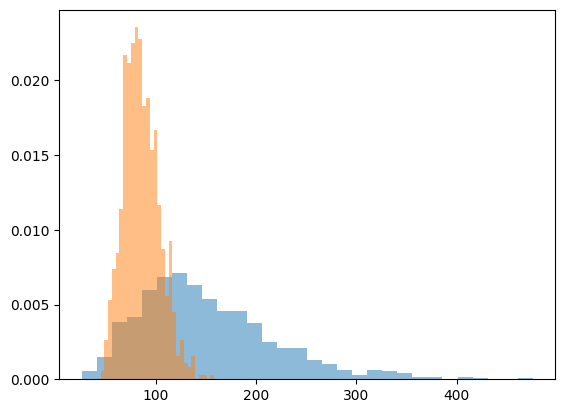

In [17]:
plt.hist(np.exp(df_log[Y_log_cols[2]][sel]), bins=30, alpha=0.5, label='Soup',density=True);
plt.hist(soup_prize_samples, bins=30, alpha=0.5, label='Soup',density=True);
print(expected_3[2])
print(np.mean(soup_prize_samples))


vary other prizes and keep soup constant:

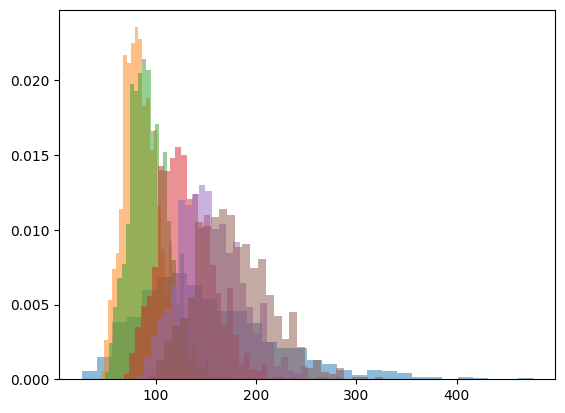

In [18]:
plt.hist(np.exp(df_log[Y_log_cols[2]][sel]), bins=30, alpha=0.5, label='Soup',density=True);


prices = [4.50, 6.0, 4.50, 0.80]
samples = sample_joint_demand_posterior_efficient(prices, num_samples, forecaster_obj)
soup_prize_samples=[]
for i in range(0,num_samples):
    soup_prize_samples.append(samples[i][2])
plt.hist(soup_prize_samples, bins=30, alpha=0.5, label='Soup',density=True);

prices = [4.00, 5.0, 4.50, 0.80]
samples = sample_joint_demand_posterior_efficient(prices, num_samples, forecaster_obj)
soup_prize_samples=[]
for i in range(0,num_samples):
    soup_prize_samples.append(samples[i][2])
plt.hist(soup_prize_samples, bins=30, alpha=0.5, label='Soup',density=True);

prices = [4.00, 5.0, 4.50, 1.80]
samples = sample_joint_demand_posterior_efficient(prices, num_samples, forecaster_obj)
soup_prize_samples=[]
for i in range(0,num_samples):
    soup_prize_samples.append(samples[i][2])
plt.hist(soup_prize_samples, bins=30, alpha=0.5, label='Soup',density=True);

prices = [4.00, 4.5, 4.50, 2.80]
samples = sample_joint_demand_posterior_efficient(prices, num_samples, forecaster_obj)
soup_prize_samples=[]
for i in range(0,num_samples):
    soup_prize_samples.append(samples[i][2])
plt.hist(soup_prize_samples, bins=30, alpha=0.5, label='Soup',density=True);


prices = [3.5, 4.0, 4.50, 3.0]
samples = sample_joint_demand_posterior_efficient(prices, num_samples, forecaster_obj)
soup_prize_samples=[]
for i in range(0,num_samples):
    soup_prize_samples.append(samples[i][2])
plt.hist(soup_prize_samples, bins=30, alpha=0.5, label='Soup',density=True);

depending on other prices the demand distribution of soup changes - this is modeled by the OLS model including the covariance to create a probabilistic forecast sampler


So this is more than just looking at the histogram of one prize-demand pair isolated - it models also the interconnections between the products (how each other prize influences the demand of other product too...)

## own approaches

### simple (deterministic) linear regression

MAE: 836.0402415277035
R² : 0.5787309903936467
MAE: 1.1783969210869956
R² : 0.865107459613271


Text(0, 0.5, 'Predicted (lin scale)')

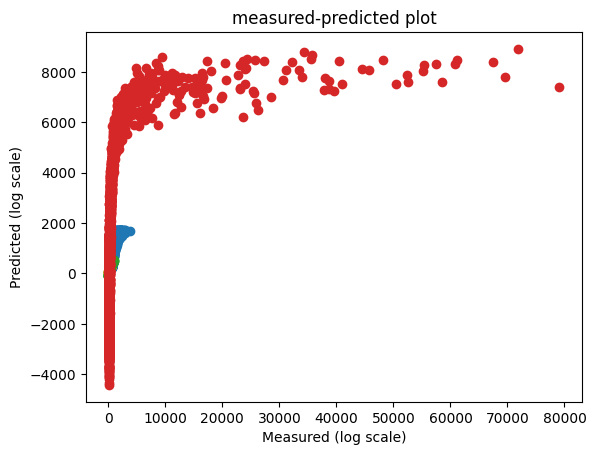

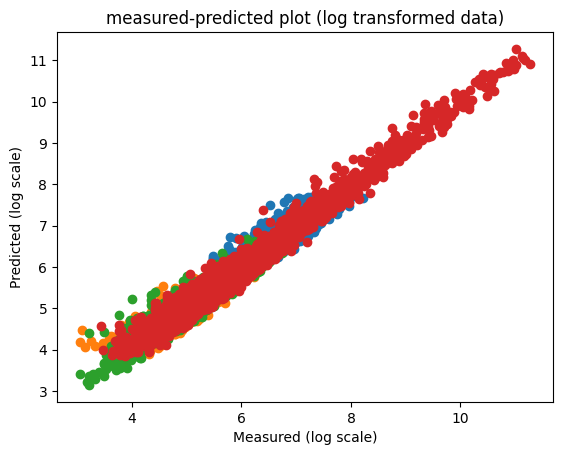

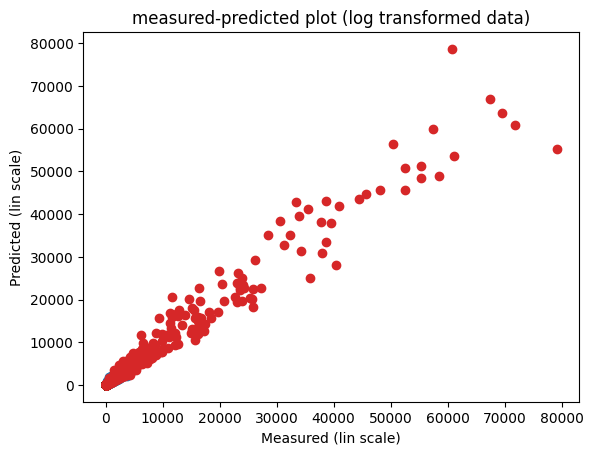

In [19]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score


X = df_data[X_cols]
y = df_data[Y_cols]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = Ridge(alpha=1.0)                # try Lasso, ElasticNet, etc.
model.fit(X_train, y_train)
pred = model.predict(X_test)
print('MAE:', mean_absolute_error(y_test, pred))
print('R² :', r2_score(y_test, pred))

plt.figure()
plt.title('measured-predicted plot')
plt.plot(y_test,pred,marker='o', linestyle='');
plt.xlabel('Measured (log scale)')
plt.ylabel('Predicted (log scale)')


X = df_log[X_log_cols]
y = df_log[Y_log_cols]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = Ridge(alpha=1.0)                # try Lasso, ElasticNet, etc.
model.fit(X_train, y_train)
pred = model.predict(X_test)
print('MAE:', np.exp(mean_absolute_error(y_test, pred)))
print('R² :', r2_score(y_test, pred))

plt.figure()
plt.title('measured-predicted plot (log transformed data)')
plt.plot(y_test,pred,marker='o', linestyle='');
plt.xlabel('Measured (log scale)')
plt.ylabel('Predicted (log scale)')

plt.figure()
plt.title('measured-predicted plot (log transformed data)')
plt.plot(np.exp(y_test),np.exp(pred),marker='o', linestyle='');
plt.xlabel('Measured (lin scale)')
plt.ylabel('Predicted (lin scale)')

obviously, as seen before, log transform is needed before applying linear regression...
but, this approach allows afterwards a simple point forecast model (no uncertainty)--> adding the covariance as above is a first step into probabilistic forecaster!

pros: easy, fast & interpretable coefficients

### XGboost - handle the nonlinearity

MAE: 152.84060668945312
R² : 0.8414862155914307


Text(0, 0.5, 'Predicted (lin scale)')

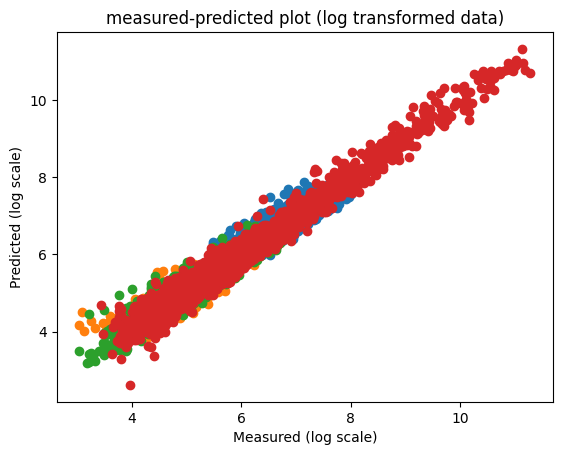

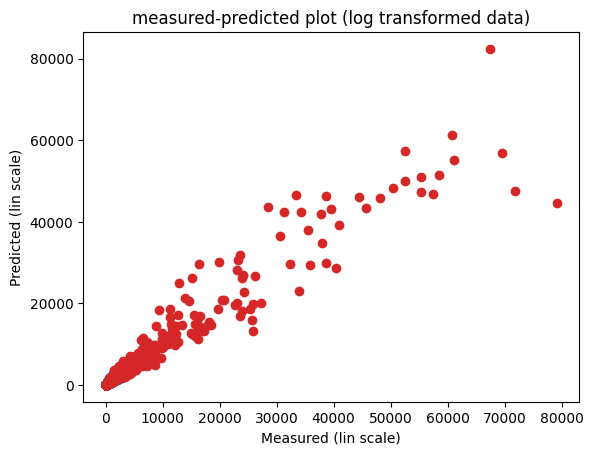

In [20]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, r2_score

X = df_data[X_cols]
y = df_data[Y_cols]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

params = {
    'objective': 'reg:squarederror',
    'eval_metric': 'mae',
    'max_depth': 6,
    'eta': 0.1,
}

# Train a separate XGBoost regressor for each target column
models = {}
preds = []
for i, target in enumerate(Y_cols):
    dtrain = xgb.DMatrix(X_train, label=y_train[target])
    dtest = xgb.DMatrix(X_test)
    bst = xgb.train(params, dtrain, num_boost_round=200, evals=[(dtrain, 'train')], early_stopping_rounds=20, verbose_eval=False)
    pred = bst.predict(dtest)
    preds.append(pred)
    models[target] = bst

# Stack predictions to shape (n_samples, n_targets)
preds = np.column_stack(preds)

print('MAE:', mean_absolute_error(y_test, preds))
print('R² :', r2_score(y_test, preds))

plt.figure()
plt.title('measured-predicted plot (log transformed data)')
plt.plot(np.log(y_test),np.log(preds),marker='o', linestyle='');
plt.xlabel('Measured (log scale)')
plt.ylabel('Predicted (log scale)')

plt.figure()
plt.title('measured-predicted plot (log transformed data)')
plt.plot(y_test,preds,marker='o', linestyle='');
plt.xlabel('Measured (lin scale)')
plt.ylabel('Predicted (lin scale)')

XGboost can handle the nonlinear relation even without the log transformation - but still just a point estimate!

## Probabilistic Modeling Approaches

### Bayesian Linear Regression

use sklearn.linear_model.BayesianRidge instead of Ridge() as before

MAE: (log scale) 0.16415412469960688
MAE: (lin scale) 130.288436050839
R² : 0.865106896171639


Text(0, 0.5, 'Predicted (lin scale)')

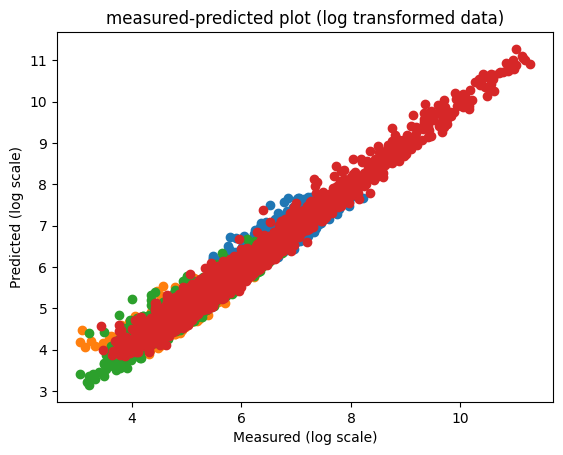

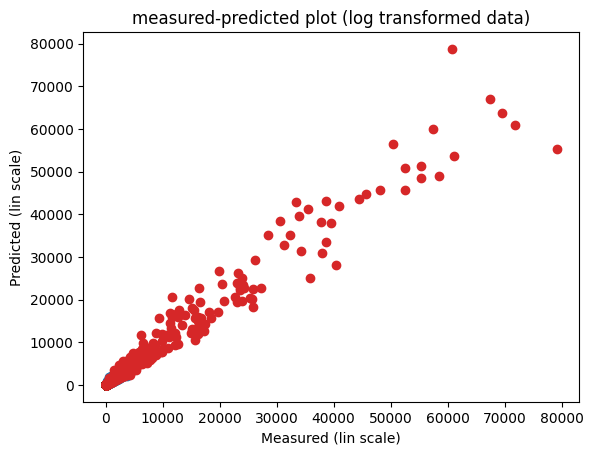

In [21]:
from sklearn.linear_model import BayesianRidge
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

X = df_log[X_log_cols]
y = df_log[Y_log_cols]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {}
preds = []
stds = []
for target in Y_log_cols:
    model = BayesianRidge()
    model.fit(X_train, y_train[target])
    pred, std = model.predict(X_test,return_std=True)
    preds.append(pred)
    stds.append(std)
    models[target] = model

# Stack predictions to shape (n_samples, n_targets)
preds = np.column_stack(preds)
stds = np.column_stack(stds)

print('MAE: (log scale)', mean_absolute_error(y_test, preds))
print('MAE: (lin scale)', mean_absolute_error(np.exp(y_test), np.exp(preds)))
print('R² :', r2_score(y_test, preds))

plt.figure()
plt.title('measured-predicted plot (log transformed data)')
plt.plot(y_test, preds, marker='o', linestyle='')
plt.xlabel('Measured (log scale)')
plt.ylabel('Predicted (log scale)')

plt.figure()
plt.title('measured-predicted plot (log transformed data)')
plt.plot(np.exp(y_test), np.exp(preds), marker='o', linestyle='')
plt.xlabel('Measured (lin scale)')
plt.ylabel('Predicted (lin scale)')

compare this result with the OLS+Sigma from the Colab:

e:\Projects\github\weekly_puzzles\price_optimization\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but BayesianRidge was fitted with feature names
  warnings.warn(
e:\Projects\github\weekly_puzzles\price_optimization\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but BayesianRidge was fitted with feature names
  warnings.warn(


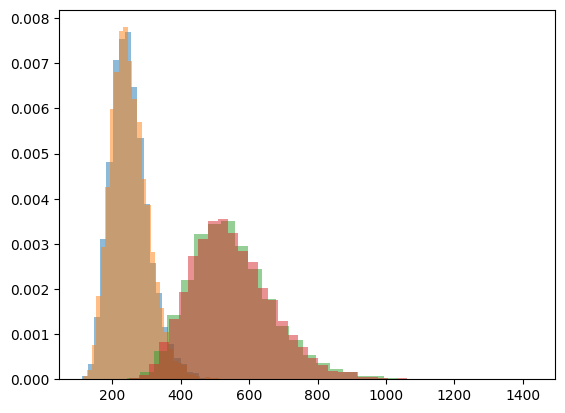

In [22]:
# test and compare to previous sampler:
num_samples=10000
# previous sampler from solution proposal
prices = [3.5, 4.0, 3.50, 3.0]
samples = sample_joint_demand_posterior_efficient(prices, num_samples, forecaster_obj)
soup_prize_samples=[]
for i in range(0,num_samples):
    soup_prize_samples.append(samples[i][2])
plt.hist(soup_prize_samples, bins=30, alpha=0.5, label='Soup',density=True);

# sampling from the new model:
target = Y_log_cols[2]
model = BayesianRidge()
model.fit(X_train, y_train[target])
pred, std = model.predict(np.log(prices).reshape(1, -1),return_std=True)
soup_prize_samples=[]

soup_prize_samples = np.random.normal(pred, std,num_samples)
plt.hist(np.exp(soup_prize_samples), bins=30, alpha=0.5, label='Soup',density=True);


# previous sampler from solution proposal
prices = [1.5, 2.4, 3.50, 4.0]
samples = sample_joint_demand_posterior_efficient(prices, num_samples, forecaster_obj)
soup_prize_samples=[]
for i in range(0,num_samples):
    soup_prize_samples.append(samples[i][2])
plt.hist(soup_prize_samples, bins=30, alpha=0.5, label='Soup',density=True);

# sampling from the new model:
target = Y_log_cols[2]
model = BayesianRidge()
model.fit(X_train, y_train[target])
pred, std = model.predict(np.log(prices).reshape(1, -1),return_std=True)
soup_prize_samples=[]

soup_prize_samples = np.random.normal(pred, std,num_samples)
plt.hist(np.exp(soup_prize_samples), bins=30, alpha=0.5, label='Soup',density=True);

as one can see, the results is very similar, indicating that the proposed forecaster is a kind of own implementation of what a Bayesian Linear Regression by sklearn.linear_model.BayesianRidge provides.

### asking a prominent AI assistant about other possible approaches:

Here are a few modeling options depending on your goals and data characteristics:
- Option A: Bayesian Linear Regression
    - Models demand as a linear function of prices.
    - Outputs a posterior distribution over demand (mean + variance).
    - Good for interpretability and small datasets.

- Option B: Gaussian Process Regression (GPR)
    - Non-parametric, flexible model.
    - Gives a full predictive distribution (mean + variance) for each input.
    - Works well with small to medium datasets.

- Option C: Quantile Regression Forests or Gradient Boosting
    - Tree-based models that estimate quantiles of the demand distribution.
    - Useful if demand is non-Gaussian or has skewed distributions.

- Option D: Deep Learning with Probabilistic Outputs
    - Neural networks with probabilistic layers (e.g., using TensorFlow Probability or Pyro).
    - Can model complex nonlinear relationships and output distributions.


## as we are in 2025, let's try a deep learning approach...

In [30]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

# Prepare data as torch tensors
X_train_torch = torch.tensor(X_train.values, dtype=torch.float32)
y_train_torch = torch.tensor(y_train.values, dtype=torch.float32)
X_test_torch = torch.tensor(X_test.values, dtype=torch.float32)
y_test_torch = torch.tensor(y_test.values, dtype=torch.float32)

n_targets = y.shape[1]
input_dim = X.shape[1]

class GaussianRegressor(nn.Module):
    def __init__(self, input_dim, n_targets):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU()
        )
        self.mean = nn.Linear(64, n_targets)
        self.log_std = nn.Linear(64, n_targets)
    def forward(self, x):
        x = self.net(x)
        mean = self.mean(x)
        log_std = self.log_std(x)
        return mean, log_std

model = GaussianRegressor(input_dim, n_targets)
optimizer = optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.GaussianNLLLoss(full=True)  # full=True for multivariate

# Training loop
epochs = 50
batch_size = 128*2
for epoch in range(epochs):
    permutation = torch.randperm(X_train_torch.size(0))
    for i in range(0, X_train_torch.size(0), batch_size):
        indices = permutation[i:i+batch_size]
        batch_x, batch_y = X_train_torch[indices], y_train_torch[indices]
        optimizer.zero_grad()
        mean, log_std = model(batch_x)
        var = torch.exp(log_std) ** 2  # variance for GaussianNLLLoss
        loss = loss_fn(mean, batch_y, var)
        loss.backward()
        optimizer.step()
    if (epoch+1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

# Predict mean and std for test set
model.eval()
with torch.no_grad():
    mean_pred, log_std_pred = model(X_test_torch)
    mean_pred = mean_pred.numpy()
    std_pred = np.exp(log_std_pred.numpy())

Epoch 1, Loss: 3.2864
Epoch 5, Loss: 2.2140
Epoch 5, Loss: 2.2140
Epoch 10, Loss: 0.9264
Epoch 10, Loss: 0.9264
Epoch 15, Loss: -0.1389
Epoch 15, Loss: -0.1389
Epoch 20, Loss: 0.0053
Epoch 20, Loss: 0.0053
Epoch 25, Loss: -0.0511
Epoch 25, Loss: -0.0511
Epoch 30, Loss: -0.1294
Epoch 30, Loss: -0.1294
Epoch 35, Loss: -0.1508
Epoch 35, Loss: -0.1508
Epoch 40, Loss: -0.1354
Epoch 40, Loss: -0.1354
Epoch 45, Loss: -0.0912
Epoch 45, Loss: -0.0912
Epoch 50, Loss: -0.0383
Epoch 50, Loss: -0.0383


MAE: (log scale) 0.16856889426708221
MAE: (lin scale) 132.2681884765625
R² : 0.8624826669692993


Text(0, 0.5, 'Predicted (log scale)')

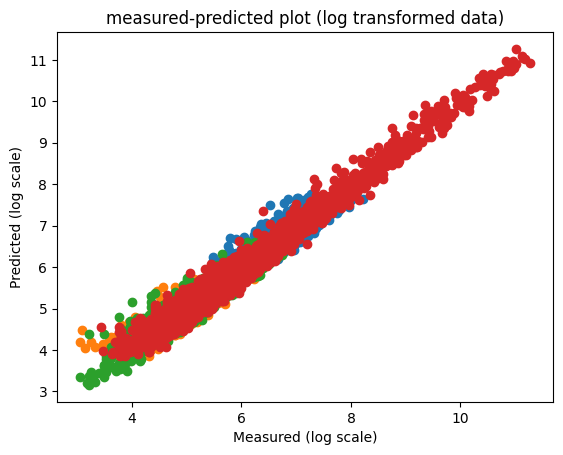

In [31]:
print('MAE: (log scale)', mean_absolute_error(y_test, mean_pred))
print('MAE: (lin scale)', mean_absolute_error(np.exp(y_test), np.exp(mean_pred)))
print('R² :', r2_score(y_test, mean_pred))

plt.figure()
plt.title('measured-predicted plot (log transformed data)')
plt.plot(y_test, mean_pred, marker='o', linestyle='')
plt.xlabel('Measured (log scale)')
plt.ylabel('Predicted (log scale)')

mean estimation is similar to the Bayesian Linear Regression / OLS+Sigma approach as above - using a deep NN for single gaussian regression is not beneficial in that case...

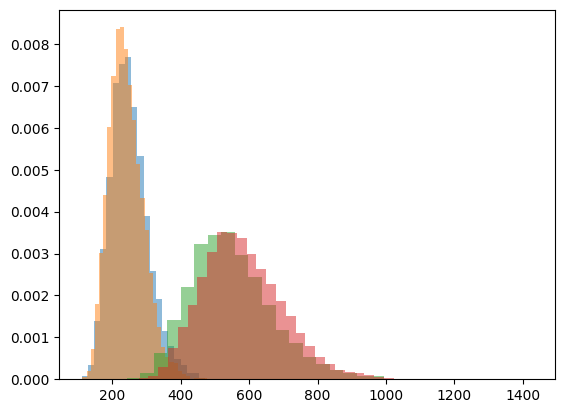

In [52]:
def model_predict(prices: List[float], model: nn.Module) -> (np.ndarray, np.ndarray):
    model.eval()
    with torch.no_grad():
        prices_torch = torch.tensor(prices, dtype=torch.float32).unsqueeze(0)
        mean_pred, log_std_pred = model(torch.log(prices_torch))
        mean_pred = mean_pred.numpy().flatten()
        std_pred = np.exp(log_std_pred.numpy().flatten())
    return mean_pred, std_pred


# test and compare to previous sampler:
num_samples=10000
# previous sampler from solution proposal
prices = [3.5, 4.0, 3.50, 3.0]
samples = sample_joint_demand_posterior_efficient(prices, num_samples, forecaster_obj)
soup_prize_samples=[]
for i in range(0,num_samples):
    soup_prize_samples.append(samples[i][2])
plt.hist(soup_prize_samples, bins=30, alpha=0.5, label='Soup',density=True);

# sampling from the new model:
mean_pred, std_pred = model_predict(prices, model)
soup_prize_samples = np.random.normal(mean_pred[2], std_pred[2], num_samples)
plt.hist(np.exp(soup_prize_samples), bins=30, alpha=0.5, label='Soup',density=True);

# previous sampler from solution proposal
prices = [1.5, 2.4, 3.50, 4.0]
samples = sample_joint_demand_posterior_efficient(prices, num_samples, forecaster_obj)
soup_prize_samples=[]
for i in range(0,num_samples):
    soup_prize_samples.append(samples[i][2])
plt.hist(soup_prize_samples, bins=30, alpha=0.5, label='Soup',density=True);

# sampling from the new model:
mean_pred, std_pred = model_predict(prices, model)
soup_prize_samples = np.random.normal(mean_pred[2], std_pred[2], num_samples)
plt.hist(np.exp(soup_prize_samples), bins=30, alpha=0.5, label='Soup',density=True);

but one can see, that in this case the distribution is slightly different - probably due to different mean that is estimated...

So what can be done?

--> use a Mixture Density Network: Instead of modeling each target as a single Gaussian, MDNs predict parameters for a mixture of Gaussians (means, stds, and weights). This allows modeling multimodal and skewed distributions. Good source for MDN is [here](https://medium.com/data-science/predicting-the-unpredictable-905f634acc20)




### Mixture Density Network (MDN) for Multimodal Demand Prediction
This cell implements an MDN for your log-transformed price/demand data, following best practices from Bishop's paper and the referenced Medium article.

In [53]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

class MDNRegressor(nn.Module):
    def __init__(self, input_dim, n_targets, n_components):
        super().__init__()
        self.n_targets = n_targets
        self.n_components = n_components
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU()
        )
        self.z_pi = nn.Linear(64, n_components)
        self.z_mu = nn.Linear(64, n_components * n_targets)
        self.z_sigma = nn.Linear(64, n_components * n_targets)
    def forward(self, x):
        h = self.net(x)
        pi = torch.softmax(self.z_pi(h), dim=-1)  # (batch, n_components)
        mu = self.z_mu(h).view(-1, self.n_components, self.n_targets)  # (batch, n_components, n_targets)
        sigma = torch.exp(self.z_sigma(h)).view(-1, self.n_components, self.n_targets)  # (batch, n_components, n_targets)
        return pi, mu, sigma

def mdn_loss(y, pi, mu, sigma):
    # y: (batch, n_targets)
    # pi: (batch, n_components)
    # mu, sigma: (batch, n_components, n_targets)
    y = y.unsqueeze(1)  # (batch, 1, n_targets)
    norm = torch.exp(-0.5 * torch.sum(((y - mu) / sigma) ** 2, dim=2))  # (batch, n_components)
    denom = torch.prod(sigma * np.sqrt(2 * np.pi), dim=2)  # (batch, n_components)
    comp_prob = norm / denom  # (batch, n_components)
    weighted = pi * comp_prob  # (batch, n_components)
    prob = torch.sum(weighted, dim=1) + 1e-8  # (batch,)
    nll = -torch.mean(torch.log(prob))
    return nll

# Hyperparameters
n_targets = y.shape[1]
input_dim = X.shape[1]
n_components = 3

# Prepare data as torch tensors
X_train_torch = torch.tensor(X_train.values, dtype=torch.float32)
y_train_torch = torch.tensor(y_train.values, dtype=torch.float32)
X_test_torch = torch.tensor(X_test.values, dtype=torch.float32)
y_test_torch = torch.tensor(y_test.values, dtype=torch.float32)

model = MDNRegressor(input_dim, n_targets, n_components)
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Training loop
epochs = 30
batch_size = 128
for epoch in range(epochs):
    permutation = torch.randperm(X_train_torch.size(0))
    for i in range(0, X_train_torch.size(0), batch_size):
        indices = permutation[i:i+batch_size]
        batch_x, batch_y = X_train_torch[indices], y_train_torch[indices]
        optimizer.zero_grad()
        pi, mu, sigma = model(batch_x)
        loss = mdn_loss(batch_y, pi, mu, sigma)
        loss.backward()
        optimizer.step()
    if (epoch+1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

# To sample from the MDN for a test point:
model.eval()
with torch.no_grad():
    pi, mu, sigma = model(X_test_torch)
    pi = pi.numpy()
    mu = mu.numpy()
    sigma = sigma.numpy()
    # Example: sample from the mixture for the first test sample
    sample_idx = 0
    n_samples = 1000
    samples = np.zeros((n_samples, n_targets))
    for i in range(n_samples):
        k = np.random.choice(n_components, p=pi[sample_idx])
        samples[i] = np.random.normal(loc=mu[sample_idx, k], scale=sigma[sample_idx, k])
    # Now samples contains draws from the predicted mixture for the first test sample

Epoch 1, Loss: 18.4207
Epoch 5, Loss: 18.4207
Epoch 5, Loss: 18.4207
Epoch 10, Loss: 18.4207
Epoch 10, Loss: 18.4207
Epoch 15, Loss: 18.4207
Epoch 15, Loss: 18.4207
Epoch 20, Loss: 18.4207
Epoch 20, Loss: 18.4207
Epoch 25, Loss: 18.4207
Epoch 25, Loss: 18.4207
Epoch 30, Loss: 18.4207
Epoch 30, Loss: 18.4207


In [ ]:
def model_predict(prices: List[float], model: nn.Module) -> (np.ndarray, np.ndarray):
    model.eval()
    with torch.no_grad():
        prices_torch = torch.tensor(prices, dtype=torch.float32).unsqueeze(0)
        pi, mu, sigma = model(torch.log(prices_torch))
        mean_pred = mu.numpy().flatten()
        std_pred = np.exp(sigma.numpy().flatten())
        # TODOOO
    return mean_pred, std_pred


# test and compare to previous sampler:
num_samples=10000
# previous sampler from solution proposal
prices = [3.5, 4.0, 3.50, 3.0]
samples = sample_joint_demand_posterior_efficient(prices, num_samples, forecaster_obj)
soup_prize_samples=[]
for i in range(0,num_samples):
    soup_prize_samples.append(samples[i][2])
plt.hist(soup_prize_samples, bins=30, alpha=0.5, label='Soup',density=True);

# sampling from the new model:
mean_pred, std_pred = model_predict(prices, model)
soup_prize_samples = np.random.normal(mean_pred[2], std_pred[2], num_samples)
plt.hist(np.exp(soup_prize_samples), bins=30, alpha=0.5, label='Soup',density=True);

In [27]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

# Prepare data (already defined above)
X = df_log[X_log_cols]
y = df_log[Y_log_cols]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

n_targets = y.shape[1]
n_components = 3  # Number of mixture components

inputs = keras.Input(shape=(X.shape[1],))
x = layers.Dense(64, activation='relu')(inputs)
x = layers.Dense(64, activation='relu')(x)

# Mixture weights (softmax), means, stds (softplus for positivity)
mix_logits = layers.Dense(n_components)(x)
means = layers.Dense(n_components * n_targets)(x)
stds = layers.Dense(n_components * n_targets, activation='softplus')(x)

def split_mdn_outputs(outputs):
    mix_logits = outputs[:, :n_components]
    means = outputs[:, n_components:n_components + n_components * n_targets]
    stds = outputs[:, n_components + n_components * n_targets:]
    means = tf.reshape(means, [-1, n_components, n_targets])
    stds = tf.reshape(stds, [-1, n_components, n_targets])
    return mix_logits, means, stds

mdn_outputs = layers.Concatenate()([mix_logits, means, stds])
model = keras.Model(inputs, mdn_outputs)

def mdn_loss(y_true, y_pred):
    mix_logits, means, stds = split_mdn_outputs(y_pred)
    # mixture weights (softmax)
    mix_weights = tf.nn.softmax(mix_logits, axis=-1)
    # Expand y_true for broadcasting
    y_true_exp = tf.expand_dims(y_true, axis=1)  # shape: (batch, 1, n_targets)
    # Compute log-prob for each component
    norm = tf.math.exp(-0.5 * tf.reduce_sum(tf.square((y_true_exp - means) / stds), axis=-1))
    denom = tf.reduce_prod(stds * np.sqrt(2.0 * np.pi), axis=-1)
    comp_pdf = norm / denom  # shape: (batch, n_components)
    weighted_pdf = mix_weights * comp_pdf
    total_pdf = tf.reduce_sum(weighted_pdf, axis=-1) + 1e-8  # avoid log(0)
    nll = -tf.reduce_mean(tf.math.log(total_pdf))
    return nll

learning_rate = 0.01
optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
model.compile(optimizer=optimizer, loss=mdn_loss)

history = model.fit(X_train, y_train, epochs=30, batch_size=128, validation_split=0.1)

Epoch 1/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 18.4207 - val_loss: 18.4207
Epoch 2/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 18.4207 - val_loss: 18.4207
Epoch 2/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 18.4207 - val_loss: 18.4207
Epoch 3/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 18.4207 - val_loss: 18.4207
Epoch 3/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 18.4207 - val_loss: 18.4207
Epoch 4/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 18.4207 - val_loss: 18.4207
Epoch 4/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 18.4207 - val_loss: 18.4207
Epoch 5/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 18.4207 - val_loss: 18.4207
Epoch 5/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 18.4207 - val_loss: 18.4207
Epoch 6/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 18.4207 - val_loss: 18.4207
Epoch 6/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 18.4207 - val_loss: 18.4207
Epoch 7/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - lo

In [28]:
# Predict mixture parameters for test set
y_pred = model.predict(X_test)
mix_logits, means, stds = split_mdn_outputs(y_pred)
mix_weights = tf.nn.softmax(mix_logits, axis=-1).numpy()
means = means.numpy()
stds = stds.numpy()

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [29]:
def get_sample_preds(alpha, sigma, mu, samples=10):
    N, K, T = mu.shape
    sampled_preds = np.zeros((N, samples, T))
    uniform_samples = np.random.rand(N, samples)
    cum_alpha = np.cumsum(alpha, axis=1)
    for i in range(N):
        for j in range(samples):
            u = uniform_samples[i, j]
            k = np.searchsorted(cum_alpha[i], u)
            sampled_preds[i, j] = np.random.normal(mu[i, k], sigma[i, k])
    return sampled_preds

# Sample from the mixture for a test point (e.g., first test sample)
n_samples = 1000

'''
sample_idx = 0  # Pick first test sample
weights = mix_weights[sample_idx]
means_ = means[sample_idx]  # shape: (n_components, n_targets)
stds_ = stds[sample_idx]
samples = np.zeros((n_samples, n_targets))
for i in range(n_samples):
    k = np.random.choice(n_components, p=weights)
    samples[i] = np.random.normal(loc=means_[k], scale=stds_[k])
'''

samples = get_sample_preds(mix_logits, stds, means, samples=n_samples)

# Plot histogram for one target (e.g., Soup)
target_idx = 2  # Soup
plt.figure(figsize=(8, 5))
plt.hist(samples[:, target_idx], bins=30, alpha=0.5, label='MDN samples', density=True)
plt.hist(y_test[:, target_idx], bins=30, alpha=0.5, label='Empirical test', density=True)
plt.title('MDN vs Empirical Histogram (log scale) - Soup')
plt.xlabel('log(Demand)')
plt.ylabel('Density')
plt.legend()
plt.show()

IndexError: index 3 is out of bounds for axis 1 with size 3

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

# Prepare data (already defined above)
# X = df_log[X_log_cols]
# y = df_log[Y_log_cols]
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

n_targets = y.shape[1]
n_components = 3  # Number of mixture components

inputs = keras.Input(shape=(X.shape[1],))
x = layers.Dense(64, activation='relu')(inputs)
x = layers.Dense(64, activation='relu')(x)

# Mixture weights (softmax), means, stds (softplus for positivity)
mix_logits = layers.Dense(n_components)(x)
means = layers.Dense(n_components * n_targets)(x)
stds = layers.Dense(n_components * n_targets, activation='softplus')(x)

def split_mdn_outputs(outputs):
    mix_logits = outputs[:, :n_components]
    means = outputs[:, n_components:n_components + n_components * n_targets]
    stds = outputs[:, n_components + n_components * n_targets:]
    means = tf.reshape(means, [-1, n_components, n_targets])
    stds = tf.reshape(stds, [-1, n_components, n_targets])
    return mix_logits, means, stds

mdn_outputs = layers.Concatenate()([mix_logits, means, stds])
model = keras.Model(inputs, mdn_outputs)

def mdn_loss(y_true, y_pred):
    mix_logits, means, stds = split_mdn_outputs(y_pred)
    # mixture weights (softmax)
    mix_weights = tf.nn.softmax(mix_logits, axis=-1)
    # Expand y_true for broadcasting
    y_true_exp = tf.expand_dims(y_true, axis=1)  # shape: (batch, 1, n_targets)
    # Compute log-prob for each component
    norm = tf.math.exp(-0.5 * tf.reduce_sum(tf.square((y_true_exp - means) / stds), axis=-1))
    denom = tf.reduce_prod(stds * np.sqrt(2.0 * np.pi), axis=-1)
    comp_pdf = norm / denom  # shape: (batch, n_components)
    weighted_pdf = mix_weights * comp_pdf
    total_pdf = tf.reduce_sum(weighted_pdf, axis=-1) + 1e-8  # avoid log(0)
    nll = -tf.reduce_mean(tf.math.log(total_pdf))
    return nll

learning_rate = 0.01
optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
model.compile(optimizer=optimizer, loss=mdn_loss)

history = model.fit(X_train, y_train, epochs=30, batch_size=128, validation_split=0.1)

Epoch 1/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 18.4207 - val_loss: 18.4207
Epoch 2/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 18.4207 - val_loss: 18.4207
Epoch 3/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 18.4207 - val_loss: 18.4207
Epoch 4/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 18.4207 - val_loss: 18.4207
Epoch 5/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 18.4207 - val_loss: 18.4207
Epoch 6/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 18.4207 - val_loss: 18.4207
Epoch 7/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 18.4207 - val_loss: 18.4207
Epoch 8/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 18.4207 - val_loss: 18.4207
Epoch 9/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 18.4207 - val_loss: 18.4207
Epoch 10/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 18.4207 - val_loss: 18.4207
Epoch 11/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 18.4207 - val_loss: 18.4207
Epoch 12/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step -

In [ ]:
# Predict mixture parameters for test set
y_pred = model.predict(X_test)
mix_logits, means, stds = split_mdn_outputs(y_pred)
mix_weights = tf.nn.softmax(mix_logits, axis=-1).numpy()
means = means.numpy()
stds = stds.numpy()

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [ ]:
def get_sample_preds(alpha, sigma, mu, samples=10):
    N, K, T = mu.shape
    sampled_preds = np.zeros((N, samples, T))
    uniform_samples = np.random.rand(N, samples)
    cum_alpha = np.cumsum(alpha, axis=1)
    for i in range(N):
        for j in range(samples):
            u = uniform_samples[i, j]
            k = np.searchsorted(cum_alpha[i], u)
            sampled_preds[i, j] = np.random.normal(mu[i, k], sigma[i, k])
    return sampled_preds

# Sample from the mixture for a test point (e.g., first test sample)
n_samples = 1000

'''
sample_idx = 0  # Pick first test sample
weights = mix_weights[sample_idx]
means_ = means[sample_idx]  # shape: (n_components, n_targets)
stds_ = stds[sample_idx]
samples = np.zeros((n_samples, n_targets))
for i in range(n_samples):
    k = np.random.choice(n_components, p=weights)
    samples[i] = np.random.normal(loc=means_[k], scale=stds_[k])
'''

samples = get_sample_preds(mix_logits, stds, means, samples=n_samples)

# Plot histogram for one target (e.g., Soup)
target_idx = 2  # Soup
plt.figure(figsize=(8, 5))
plt.hist(samples[:, target_idx], bins=30, alpha=0.5, label='MDN samples', density=True)
plt.hist(y_test[:, target_idx], bins=30, alpha=0.5, label='Empirical test', density=True)
plt.title('MDN vs Empirical Histogram (log scale) - Soup')
plt.xlabel('log(Demand)')
plt.ylabel('Density')
plt.legend()
plt.show()

IndexError: index 3 is out of bounds for axis 1 with size 3

In [ ]:
import numpy as np
def get_sample_preds_tf(alpha, sigma, mu, samples=10):
    # alpha: (N, K), sigma: (N, K, T), mu: (N, K, T)
    N, K, T = mu.shape
    sampled_preds = np.zeros((N, samples, T))
    uniform_samples = np.random.rand(N, samples)
    cum_alpha = np.cumsum(alpha, axis=1)
    for i in range(N):
        for j in range(samples):
            u = uniform_samples[i, j]
            k = np.searchsorted(cum_alpha[i], u)
            sampled_preds[i, j] = np.random.normal(mu[i, k], sigma[i, k])
    return sampled_preds